In [155]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Load your cleaned dataset
df = pd.read_csv(
    "/Users/kevinfinn/Documents/Linear Regression Project/marketing-roi-linear-regression/data/processed/df_clean.csv",  # adjust if needed
    parse_dates=["date"]
)

df.head()

,google_ads_spend_log,facebook_ads_spend_log,email_marketing_spend_log,influencer_spend_log,organic_traffic,email_sends,site_visits,conversions,revenue,google_ads_spend_missing,facebook_ads_spend_missing,email_marketing_spend_missing,influencer_spend_missing,organic_traffic_missing,email_sends_missing,site_visits_missing,conversions_missing,date,google_ads_spend_log_lag1,google_ads_spend_log_lag3,google_ads_spend_log_lag7,facebook_ads_spend_log_lag1,facebook_ads_spend_log_lag3,facebook_ads_spend_log_lag7,email_marketing_spend_log_lag1,email_marketing_spend_log_lag3,email_marketing_spend_log_lag7,influencer_spend_log_lag1,influencer_spend_log_lag3,influencer_spend_log_lag7,organic_traffic_lag1,organic_traffic_lag3,organic_traffic_lag7,email_sends_lag1,email_sends_lag3,email_sends_lag7,site_visits_lag1,site_visits_lag3,site_visits_lag7,conversions_lag1,...,email_marketing_spend_log_roll6,email_marketing_spend_log_roll7,influencer_spend_log_roll1,influencer_spend_log_roll2,influencer_spend_log_roll3,influencer_spend_log_roll4,influencer_spend_log_roll5,influencer_spend_log_roll6,influencer_spend_log_roll7,organic_traffic_roll1,organic_traffic_roll2,organic_traffic_roll3,organic_traffic_roll4,organic_traffic_roll5,organic_traffic_roll6,organic_traffic_roll7,email_sends_roll1,email_sends_roll2,email_sends_roll3,email_sends_roll4,email_sends_roll5,email_sends_roll6,email_sends_roll7,site_visits_roll1,site_visits_roll2,site_visits_roll3,site_visits_roll4,site_visits_roll5,site_visits_roll6,site_visits_roll7,conversions_roll1,conversions_roll2,conversions_roll3,conversions_roll4,conversions_roll5,conversions_roll6,conversions_roll7,day_of_week,is_weekend,month
0,0.330639,-1.497778,0.508957,-0.042318,-0.431001,0.096983,-1.480853,-0.705973,-8969.378951,0,0,0,0,0,0,0,0,2024-01-01,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,NaN,NaN,-0.042318,NaN,NaN,NaN,NaN,NaN,NaN,-0.431001,NaN,NaN,NaN,NaN,NaN,NaN,0.096983,NaN,NaN,NaN,NaN,NaN,NaN,-1.480853,NaN,NaN,NaN,NaN,NaN,NaN,-0.705973,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1
1,-0.172202,-0.134738,0.000000,-0.776036,0.362508,0.668100,0.820817,0.243462,4996.218917,0,0,1,0,0,0,0,0,2024-01-02,0.330639,0.000000,0.0,-1.497778,0.000000,0.0,0.508957,0.000000,0.0,-0.042318,0.000000,0.0,-0.431001,0.000000,0.0,0.096983,0.000000,0.0,-1.480853,0.000000,0.0,-0.705973,...,NaN,NaN,-0.776036,-0.409177,NaN,NaN,NaN,NaN,NaN,0.362508,-0.034246,NaN,NaN,NaN,NaN,NaN,0.668100,0.382542,NaN,NaN,NaN,NaN,NaN,0.820817,-0.330018,NaN,NaN,NaN,NaN,NaN,0.243462,-0.231256,NaN,NaN,NaN,NaN,NaN,1,0,1
2,-0.255385,0.002005,-0.962783,-0.460985,-2.276035,0.640554,0.772678,-0.949354,4703.488945,0,0,0,0,0,0,0,0,2024-01-03,-0.172202,0.000000,0.0,-0.134738,0.000000,0.0,0.000000,0.000000,0.0,-0.776036,0.000000,0.0,0.362508,0.000000,0.0,0.668100,0.000000,0.0,0.820817,0.000000,0.0,0.243462,...,NaN,NaN,-0.460985,-0.618511,-0.426446,NaN,NaN,NaN,NaN,-2.276035,-0.956764,-0.781509,NaN,NaN,NaN,NaN,0.640554,0.654327,0.468546,NaN,NaN,NaN,NaN,0.772678,0.796747,0.037547,NaN,NaN,NaN,NaN,-0.949354,-0.352946,-0.470622,NaN,NaN,NaN,NaN,2,0,1
3,-0.255371,-1.563605,-0.254954,-1.385825,0.788624,-1.191803,0.683390,0.066782,1857.547269,0,0,0,0,0,0,0,0,2024-01-04,-0.255385,0.330639,0.0,0.002005,-1.497778,0.0,-0.962783,0.508957,0.0,-0.460985,-0.042318,0.0,-2.276035,-0.431001,0.0,0.640554,0.096983,0.0,0.772678,-1.480853,0.0,-0.949354,...,NaN,NaN,-1.385825,-0.923405,-0.874282,-0.666291,NaN,NaN,NaN,0.788624,-0.743706,-0.374968,-0.388976,NaN,NaN,NaN,-1.191803,-0.275625,0.038950,0.053458,NaN,NaN,NaN,0.683390,0.728034,0.758962,0.199008,NaN,NaN,NaN,0.066782,-0.441286,-0.213037,-0.336271,NaN,NaN,NaN,3,0,1
4,1.040750,-0.331261,-1.435837,1.081788,1.101198,1.558699,0.302509,0.359725,7763.494686,0,0,0,0,0,0,0,0,2024-01-05,-0.255371,-0.172202,0.0,-1.563605,-0.134738,0.0,-0.254954,0.000000,0.0,-1.385825,-0.776036,0.0,0.788624,0.362508,0.0,-1.191803,0.668100,0.0,0.683390,0.8

In [156]:
# Drop non-feature columns
X = df.drop(columns=["revenue", "date"])
y = df["revenue"]

print("Feature count:", X.shape[1])

Feature count: 167


In [157]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [158]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [159]:
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R²:", r2)
print("MSE:", mse)

R²: 0.017531571862536288
MSE: 22355254.697054766


In [160]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
108,google_ads_spend_log_roll1,0.041945
0,google_ads_spend_log,0.034985
72,google_ads_spend_log_cube,0.034980
34,site_visits_lag1,0.020152
30,organic_traffic_lag7,0.019359
36,site_visits_lag7,0.018629
96,email_marketing_spend_log_x_site_visits,0.014923
64,google_ads_spend_log_sq,0.013571
82,google_ads_spend_log_x_influencer_spend_log,0.011672
71,conversions_sq,0.011335


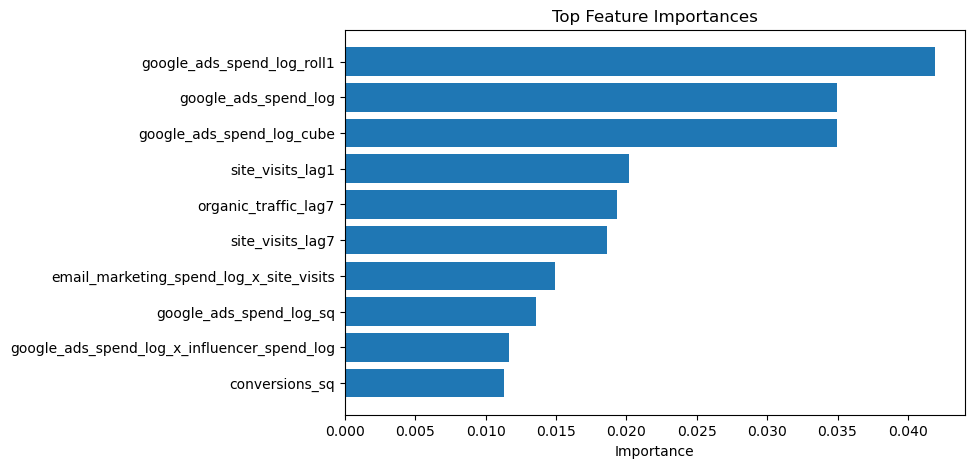

In [161]:
import matplotlib.pyplot as plt

top_n = 10
fi = feature_importance.head(top_n)

plt.figure(figsize=(8,5))
plt.barh(fi["feature"], fi["importance"])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.show()

Try random forests/linear regression with different datasets

In [162]:
import pandas as pd
import numpy as np

# Ensure sorted by date
df = df.sort_values("date").reset_index(drop=True)
df.set_index("date", inplace=True)

In [163]:
df

,google_ads_spend_log,facebook_ads_spend_log,email_marketing_spend_log,influencer_spend_log,organic_traffic,email_sends,site_visits,conversions,revenue,google_ads_spend_missing,facebook_ads_spend_missing,email_marketing_spend_missing,influencer_spend_missing,organic_traffic_missing,email_sends_missing,site_visits_missing,conversions_missing,google_ads_spend_log_lag1,google_ads_spend_log_lag3,google_ads_spend_log_lag7,facebook_ads_spend_log_lag1,facebook_ads_spend_log_lag3,facebook_ads_spend_log_lag7,email_marketing_spend_log_lag1,email_marketing_spend_log_lag3,email_marketing_spend_log_lag7,influencer_spend_log_lag1,influencer_spend_log_lag3,influencer_spend_log_lag7,organic_traffic_lag1,organic_traffic_lag3,organic_traffic_lag7,email_sends_lag1,email_sends_lag3,email_sends_lag7,site_visits_lag1,site_visits_lag3,site_visits_lag7,conversions_lag1,conversions_lag3,...,email_marketing_spend_log_roll6,email_marketing_spend_log_roll7,influencer_spend_log_roll1,influencer_spend_log_roll2,influencer_spend_log_roll3,influencer_spend_log_roll4,influencer_spend_log_roll5,influencer_spend_log_roll6,influencer_spend_log_roll7,organic_traffic_roll1,organic_traffic_roll2,organic_traffic_roll3,organic_traffic_roll4,organic_traffic_roll5,organic_traffic_roll6,organic_traffic_roll7,email_sends_roll1,email_sends_roll2,email_sends_roll3,email_sends_roll4,email_sends_roll5,email_sends_roll6,email_sends_roll7,site_visits_roll1,site_visits_roll2,site_visits_roll3,site_visits_roll4,site_visits_roll5,site_visits_roll6,site_visits_roll7,conversions_roll1,conversions_roll2,conversions_roll3,conversions_roll4,conversions_roll5,conversions_roll6,conversions_roll7,day_of_week,is_weekend,month
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01,0.330639,-1.497778,0.508957,-0.042318,-0.431001,0.096983,-1.480853,-0.705973,-8969.378951,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,-0.042318,NaN,NaN,NaN,NaN,NaN,NaN,-0.431001,NaN,NaN,NaN,NaN,NaN,NaN,0.096983,NaN,NaN,NaN,NaN,NaN,NaN,-1.480853,NaN,NaN,NaN,NaN,NaN,NaN,-0.705973,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1
2024-01-02,-0.172202,-0.134738,0.000000,-0.776036,0.362508,0.668100,0.820817,0.243462,4996.218917,0,0,1,0,0,0,0,0,0.330639,0.000000,0.000000,-1.497778,0.000000,0.000000,0.508957,0.000000,0.000000,-0.042318,0.000000,0.000000,-0.431001,0.000000,0.000000,0.096983,0.000000,0.000000,-1.480853,0.000000,0.000000,-0.705973,0.000000,...,NaN,NaN,-0.776036,-0.409177,NaN,NaN,NaN,NaN,NaN,0.362508,-0.034246,NaN,NaN,NaN,NaN,NaN,0.668100,0.382542,NaN,NaN,NaN,NaN,NaN,0.820817,-0.330018,NaN,NaN,NaN,NaN,NaN,0.243462,-0.231256,NaN,NaN,NaN,NaN,NaN,1,0,1
2024-01-03,-0.255385,0.002005,-0.962783,-0.460985,-2.276035,0.640554,0.772678,-0.949354,4703.488945,0,0,0,0,0,0,0,0,-0.172202,0.000000,0.000000,-0.134738,0.000000,0.000000,0.000000,0.000000,0.000000,-0.776036,0.000000,0.000000,0.362508,0.000000,0.000000,0.668100,0.000000,0.000000,0.820817,0.000000,0.000000,0.243462,0.000000,...,NaN,NaN,-0.460985,-0.618511,-0.426446,NaN,NaN,NaN,NaN,-2.276035,-0.956764,-0.781509,NaN,NaN,NaN,NaN,0.640554,0.654327,0.468546,NaN,NaN,NaN,NaN,0.772678,0.796747,0.037547,NaN,NaN,NaN,NaN,-0.949354,-0.352946,-0.470622,NaN,NaN,NaN,NaN,2,0,1
2024-01-04,-0.255371,-1.563605,-0.254954,-1.385825,0.788624,-1.191803,0.683390,0.066782,1857.547269,0,0,0,0,0,0,0,0,-0.255385,0.330639,0.000000,0.002005,-1.497778,0.000000,-0.962783,0.508957,0.000000,-0.460985,-0.042318,0.000000,-2.276035,-0.431001,0.000000,0.640554,0.096983,0.000000,0.772678,-1.480853,0.000000,-0.949354,-0.705973,...,NaN,NaN,-1.385825,-0.923405,-0.874282,-0.666291,NaN,NaN,NaN,0.788624,-0.743706,-0.374968,-0.388976,NaN,NaN,NaN,-1.191803,-0.275625,0.038950,0.053458,NaN,NaN,NaN,0.683390,0.728034,0.758962,0.199008,NaN,NaN,NaN,0.066782,-0.441286,-0.213037,-0.336271,NaN,NaN,NaN,3,0,1


In [164]:
df_weekly = df.resample("W").sum()
df_weekly = df_weekly.dropna()

In [165]:
df_diff = df.diff().dropna()

In [166]:
df_pct = df[['google_ads_spend_log',
 'facebook_ads_spend_log',
 'email_marketing_spend_log',
 'influencer_spend_log',
 'organic_traffic',
 'email_sends',
 'site_visits',
 'conversions',
 'revenue',
]]
df_pct = df_pct.pct_change().replace([np.inf, -np.inf], np.nan).dropna()

In [167]:
df_class = df.copy()
df_class["target"] = (df_class["revenue"].diff() > 0).astype(int)
df_class = df_class.dropna()

In [168]:
core_features = [
    "google_ads_spend_log",
    "facebook_ads_spend_log",
    "organic_traffic",
    "email_sends",
    "site_visits",
    "conversions"
]

df_narrow = df[core_features + ["revenue"]].dropna()

In [169]:
df_roll = df.copy()
df_roll["revenue_roll7"] = df_roll["revenue"].rolling(window=7).mean()
df_roll = df_roll.dropna()

In [170]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score

def run_models(df_input, target_col, model_type="regression"):
    
    df_input = df_input.dropna()
    
    # Drop target
    X = df_input.drop(columns=[target_col])
    y = df_input[target_col]
    
    # 🚨 Keep only numeric columns
    X = X.select_dtypes(include=[np.number])
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    results = {}
    
    # -------- Linear Regression --------
    if model_type == "regression":
        lr = LinearRegression()
        lr.fit(X_train, y_train)
        y_pred = lr.predict(X_test)
        
        results["Linear_R2"] = r2_score(y_test, y_pred)
        results["Linear_MSE"] = mean_squared_error(y_test, y_pred)
    
    # -------- Random Forest --------
    if model_type == "regression":
        rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
        )
        
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)
        
        results["RF_R2"] = r2_score(y_test, y_pred)
        results["RF_MSE"] = mean_squared_error(y_test, y_pred)
    
    # -------- Classification --------
    if model_type == "classification":
        rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
        )
        
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)
        
        results["RF_Accuracy"] = accuracy_score(y_test, y_pred)
    
    return results

In [172]:
results = {}

# Original
results["original"] = run_models(df.reset_index(), "revenue")

# Weekly aggregate
results["weekly"] = run_models(df_weekly.reset_index(), "revenue")

# Differences
results["diff"] = run_models(df_diff.reset_index(), "revenue")

# Percent change
results["pct"] = run_models(df_pct.reset_index(), "revenue")

# Narrow feature set
results["narrow"] = run_models(df_narrow.reset_index(), "revenue")

# Rolling revenue
results["rolling"] = run_models(df_roll.reset_index(), "revenue_roll7")

# Classification
results["classification"] = run_models(df_class.reset_index(), "target", model_type="classification")

pd.DataFrame(results).T

KeyboardInterrupt: 

Try classification trees on raw data

In [173]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/raw/marketing_roi_dataset.csv",
    parse_dates=["date"]
)

df = df.sort_values("date").reset_index(drop=True)

In [174]:
# Fill missing values (simple + consistent)
for col in df.columns:
    if col != "date":
        df[col] = df[col].fillna(df[col].median())

In [175]:
# Predict whether revenue goes UP tomorrow
df["revenue_diff"] = df["revenue"].diff()
df["target_up"] = (df["revenue_diff"] > 0).astype(int)

df = df.dropna().reset_index(drop=True)

In [176]:
df_raw = df.copy()

In [177]:
lag_cols = [
    "google_ads_spend",
    "facebook_ads_spend",
    "email_marketing_spend",
    "influencer_spend",
    "organic_traffic",
    "email_sends",
    "site_visits",
    "conversions",
    "revenue"
]

df_lag = df.copy()

for col in lag_cols:
    for lag in [1, 2, 3, 4, 5, 6, 7]:
        df_lag[f"{col}_lag{lag}"] = df_lag[col].shift(lag)

df_lag = df_lag.dropna().reset_index(drop=True)

In [178]:
df_roll = df.copy()

for col in lag_cols:
    df_roll[f"{col}_roll7"] = df_roll[col].rolling(7).mean()

df_roll = df_roll.dropna().reset_index(drop=True)

In [179]:
df_diff = df.copy()

for col in lag_cols:
    df_diff[f"{col}_diff"] = df_diff[col].diff()

df_diff = df_diff.dropna().reset_index(drop=True)

In [180]:
df_narrow = df[[
    "google_ads_spend",
    "facebook_ads_spend",
    "email_sends",
    "conversions",
    "target_up"
]].copy()

In [183]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import numpy as np

def run_classification_models(df_input, target_col="target_up"):
    
    df_input = df_input.copy()
    
    # -------------------
    # Drop NA rows first (target safety)
    # -------------------
    df_input = df_input.dropna(subset=[target_col])
    
    # -------------------
    # Separate features / target
    # -------------------
    X = df_input.drop(columns=[target_col, "date"], errors="ignore")
    y = df_input[target_col]
    
    # -------------------
    # 🚨 REMOVE ALL REVENUE LEAKAGE
    # -------------------
    X = X[[col for col in X.columns if "revenue" not in col.lower()]]
    
    # -------------------
    # Keep only numeric columns
    # -------------------
    X = X.select_dtypes(include=[np.number])
    
    # -------------------
    # Handle missing values (required for sklearn)
    # -------------------
    X = X.fillna(X.median())
    
    # -------------------
    # Time-based split (NO shuffle)
    # -------------------
    split_idx = int(len(X) * 0.8)
    
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    results = {}
    
    # ===================
    # Random Forest
    # ===================
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    y_prob_rf = rf.predict_proba(X_test)[:, 1]
    
    results["RF_Accuracy"] = accuracy_score(y_test, y_pred_rf)
    results["RF_AUC"] = roc_auc_score(y_test, y_prob_rf)
    
    # ===================
    # Gradient Boosting
    # ===================
    gb = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
    
    gb.fit(X_train, y_train)
    y_pred_gb = gb.predict(X_test)
    y_prob_gb = gb.predict_proba(X_test)[:, 1]
    
    results["GB_Accuracy"] = accuracy_score(y_test, y_pred_gb)
    results["GB_AUC"] = roc_auc_score(y_test, y_prob_gb)
    
    return results

In [184]:
results = {}

results["raw"] = run_classification_models(df_raw)
results["lag"] = run_classification_models(df_lag)
results["rolling"] = run_classification_models(df_roll)
results["diff"] = run_classification_models(df_diff)
results["narrow"] = run_classification_models(df_narrow)

pd.DataFrame(results).T

,RF_Accuracy,RF_AUC,GB_Accuracy,GB_AUC
raw,0.530000,0.555856,0.510000,0.514551
lag,0.572864,0.600424,0.567839,0.590927
rolling,0.537688,0.556981,0.502513,0.499394
diff,0.585000,0.632063,0.540000,0.582358
narrow,0.550000,0.525053,0.485000,0.496050


In [201]:
for col in [
    "google_ads_spend",
    "facebook_ads_spend",
    "email_marketing_spend",
    "influencer_spend",
    "organic_traffic",
    "email_sends",
    "site_visits",
    "conversions"
]:
    df[f"{col}_momentum_3"] = df[col] - df[col].shift(3)
    df[f"{col}_momentum_7"] = df[col] - df[col].shift(7)

In [202]:
df["ads_efficiency"] = df["conversions"] / (df["google_ads_spend"] + 1)
df["traffic_efficiency"] = df["conversions"] / (df["site_visits"] + 1)
df["engagement_rate"] = df["conversions"] / (df["email_sends"] + 1)

In [203]:
df["ads_x_traffic_lag"] = df["google_ads_spend"] * df["organic_traffic"].shift(1)
df["facebook_x_email_lag"] = df["facebook_ads_spend"] * df["email_sends"].shift(1)

In [204]:
# =========================
# TARGET OPTION A: Big moves
# =========================
df["target_up_big"] = (
    df["revenue"].diff() > df["revenue"].std() * 0.5
).astype(int)

# =========================
# TARGET OPTION B: Rolling trend
# =========================
df["target_up_roll"] = (
    df["revenue"].rolling(3).mean().diff() > 0
).astype(int)

# Clean NaNs created by rolling/diff
df = df.dropna().reset_index(drop=True)

In [205]:
lag_cols = [
    "google_ads_spend",
    "facebook_ads_spend",
    "email_marketing_spend",
    "influencer_spend",
    "organic_traffic",
    "email_sends",
    "site_visits",
    "conversions"
]

df_lag = df.copy()

for col in lag_cols:
    for lag in [1, 3, 7]:
        df_lag[f"{col}_lag{lag}"] = df_lag[col].shift(lag)

df_lag = df_lag.dropna().reset_index(drop=True)

In [206]:
df_diff = df.copy()

for col in lag_cols:
    df_diff[f"{col}_diff"] = df_diff[col].diff()

df_diff = df_diff.dropna().reset_index(drop=True)

In [207]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import numpy as np

def run_classification_models(df_input, target_col):
    
    df_input = df_input.copy()
    
    # Drop NA in target
    df_input = df_input.dropna(subset=[target_col])
    
    # Features / target
    X = df_input.drop(columns=[target_col, "date"], errors="ignore")
    y = df_input[target_col]
    
    # 🚨 Remove leakage
    X = X[[col for col in X.columns if "revenue" not in col.lower()]]
    
    # Numeric only
    X = X.select_dtypes(include=[np.number])
    
    # Fill NaNs
    X = X.fillna(X.median())
    
    # Time split
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    results = {}
    
    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    y_prob_rf = rf.predict_proba(X_test)[:, 1]
    
    results["RF_Accuracy"] = accuracy_score(y_test, y_pred_rf)
    results["RF_AUC"] = roc_auc_score(y_test, y_prob_rf)
    
    # Gradient Boosting
    gb = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
    
    gb.fit(X_train, y_train)
    y_pred_gb = gb.predict(X_test)
    y_prob_gb = gb.predict_proba(X_test)[:, 1]
    
    results["GB_Accuracy"] = accuracy_score(y_test, y_pred_gb)
    results["GB_AUC"] = roc_auc_score(y_test, y_prob_gb)
    
    return results

In [208]:
results = {}

# -------- LAG DATASET --------
results["lag_big_target"] = run_classification_models(df_lag, "target_up_big")
results["lag_roll_target"] = run_classification_models(df_lag, "target_up_roll")

# -------- DIFF DATASET --------
results["diff_big_target"] = run_classification_models(df_diff, "target_up_big")
results["diff_roll_target"] = run_classification_models(df_diff, "target_up_roll")

# View results
results_df = pd.DataFrame(results).T
results_df

,RF_Accuracy,RF_AUC,GB_Accuracy,GB_AUC
lag_big_target,0.826531,0.900998,0.811224,0.883852
lag_roll_target,0.663265,0.735776,0.632653,0.679403
diff_big_target,0.842640,0.913833,0.837563,0.890470
diff_roll_target,0.654822,0.726606,0.619289,0.655856
